In [2]:
# Importação das bibliotecas
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Definicação do caminho do arquivo
DATA_PATH = '../data/telcon-churn.csv'

In [3]:
# Carregamento do dataset e padronizando as colunas e dados
def load_and_preprocess_columns(path):
    """
    Carregamento do dataset e limpeza das colunas
    """
    try:
        df = pd.read_csv(path)
        # Converte para minúsculas e remove espaços indesejados
        df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]
        return df
    
    except Exception as e:
        print(f"Erro ao carregar os dados: {e}")
        return pd.DataFrame()
    
# Execução do arquivo    
telcon_churn = load_and_preprocess_columns(DATA_PATH)

In [4]:
# Visualização do arquivo
display(telcon_churn.head())

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Visão geral do dataset
telcon_churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   str    
 4   dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   str    
 7   multiplelines     7043 non-null   str    
 8   internetservice   7043 non-null   str    
 9   onlinesecurity    7043 non-null   str    
 10  onlinebackup      7043 non-null   str    
 11  deviceprotection  7043 non-null   str    
 12  techsupport       7043 non-null   str    
 13  streamingtv       7043 non-null   str    
 14  streamingmovies   7043 non-null   str    
 15  contract          7043 non-null   str    
 16  paperlessbilling  7043 non-null   str    
 17  paymen

In [6]:
# Tratamento da coluna 'TotalCharges'
# erros='coerce' transforma string inváidas em NaN para tratamento
telcon_churn['totalcharges'] = pd.to_numeric(telcon_churn['totalcharges'], errors='coerce')

# Preenchendo valores vazios resultantes da conversão
telcon_churn['totalcharges'] = telcon_churn['totalcharges'].fillna(0)

In [7]:
# Regra de negócio: Se o cliente tem tenure 0, o faturamento total acumulado é 0
# Análise dos clientes com Tenure == 0
new_customers = telcon_churn[telcon_churn['tenure'] == 0]

print(new_customers['tenure'])

488     0
753     0
936     0
1082    0
1340    0
3331    0
3826    0
4380    0
5218    0
6670    0
6754    0
Name: tenure, dtype: int64


Clientes com tempo de casa (tenure) igual a zero representam o "Cold Start" da nossa operação. 
Eles acabaram de assinar o serviço e ainda não completaram o primeiro ciclo de faturamento. 
Para o cálculo de Churn, eles são problemáticos pois ainda não tiveram a oportunidade real 
de cancelar ou renovar. Frequentemente, esses dados são excluídos de modelos preditivos 
de comportamento para evitar que o modelo aprenda que "faturamento baixo" (por ser início) 
é preditor de cancelamento.

In [8]:
# Removendo o 'CustomerID' baixo valor preditivo 
telcon_churn.drop(columns=['customerid'], inplace=True)

In [9]:
# Visualização do novo DataFrame
telcon_churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   seniorcitizen     7043 non-null   int64  
 2   partner           7043 non-null   str    
 3   dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   phoneservice      7043 non-null   str    
 6   multiplelines     7043 non-null   str    
 7   internetservice   7043 non-null   str    
 8   onlinesecurity    7043 non-null   str    
 9   onlinebackup      7043 non-null   str    
 10  deviceprotection  7043 non-null   str    
 11  techsupport       7043 non-null   str    
 12  streamingtv       7043 non-null   str    
 13  streamingmovies   7043 non-null   str    
 14  contract          7043 non-null   str    
 15  paperlessbilling  7043 non-null   str    
 16  paymentmethod     7043 non-null   str    
 17  monthl

In [10]:
# Visualização dos dados
display(telcon_churn.head())

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Resumo - Limpeza e Regras de negócios

Nesta etapa inicial, preparamos os dados para que nossas análises futuras não sejam baseadas em "ruído", mas sim em dados que refletem a realidade financeira da empresa.

**Saneamento Financeiro:** Convertemos a coluna `TotalCharges` para o formato numérico. Isso foi vital porque espaços vazios em strings impediriam qualquer cálculo de **LTV** ou faturamento total, que são o coração da nossa métrica de negócio.

**Tratamento de Novos Clientes (Tenure = 0):** Identificamos os clientes que acabaram de entrar na base. Do ponto de vista de negócio, mantê-los no cálculo de Churn agora seria um erro estratégico, pois eles ainda estão na fase de Onboarding e não tiveram tempo hábil para cancelar, o que mascararia a real taxa de perda de clientes antigos.

**Blindagem contra Overfitting:** Removemos o `customerID`. Para o negócio, o ID não carrega comportamento; para o modelo de ML, ele seria uma armadilha que o faria "decorar" nomes em vez de aprender padrões comportamentais de cancelamento.

In [11]:
# Cópia do dataset limpo
telcon_churn_cop = telcon_churn.copy()

In [12]:
# Calculando a taxa de cancelamento (Churn Rate)
churn_counts = telcon_churn_cop['churn'].value_counts()
total_customers = len(telcon_churn_cop)

churn_rate = (churn_counts['Yes'] / total_customers) * 100

print(f"Total de Clientes: {total_customers}")
print(f"Clientes em Churn: {churn_counts['Yes']}")
print(f"Churn rate da base: {churn_rate:.2f}%")

Total de Clientes: 7043
Clientes em Churn: 1869
Churn rate da base: 26.54%


In [13]:
# Análise do faturamento mensal médio
# Agrupamos por Churn e calculamos a média da coluna 'MonthlyCharges' 
monthly_charges_comparison = telcon_churn_cop.groupby('churn')['monthlycharges'].mean().reset_index()

# renomeando as colunas para clareza no report
monthly_charges_comparison.columns = ['churn status', 'ticket médio mensal']

print(monthly_charges_comparison)

  churn status  ticket médio mensal
0           No            61.265124
1          Yes            74.441332


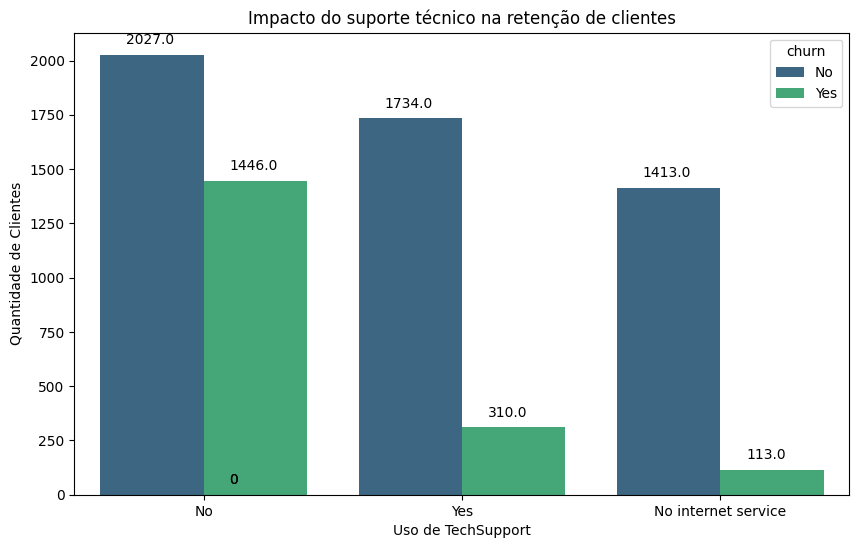

In [14]:
# Visualização Techsupport vs Churn
plt.figure(figsize=(10, 6))

# Criando um gráfico de contagem para ver a proporção de churn por tipo de soporte
ax = sns.countplot(data=telcon_churn_cop, x='techsupport', hue='churn', palette='viridis')

plt.title("Impacto do suporte técnico na retenção de clientes")
plt.xlabel("Uso de TechSupport")
plt.ylabel("Quantidade de Clientes")
plt.legend(title='churn', loc='upper right')

# COMANDO PARA SALVAR
plt.savefig('../img/graficol1.png', dpi=300, bbox_inches='tight')

# Adicionando rótulos de dados para facilitar a leitura
for p in ax.patches:
    ax.annotate(f"{p.get_height()}", (p.get_x() + 0.1, p.get_height() + 50))

plt.show()

### Conclusão da Etapa 1: EDA

Com base nas análises acima, identificamos três pontos críticos para o negócio:

**Churn Rate de 26.54%:** Esta é uma métrica alarmante para operações SaaS, indicando que perdemos mais de um quarto da base em um ciclo. O custo de aquisição de clientes (CAC) provavelmente não está sendo recuperado.

**Sensibilidade a Preço:** Clientes que deram Churn apresentam um faturamento mensal médio significativamente **maior** ($74.44) do que aqueles que permaneceram ($61.26). Isso sugere que o churn pode estar concentrado em planos mais caros ou que a percepção de valor não justifica o preço alto.

**TechSupport como Retenção:** O gráfico mostra que clientes que **não utilizam ou não têm acesso ao Suporte Técnico** têm uma propensão drasticamente maior ao Churn. Investir no Onboarding de suporte pode ser a estratégia de retenção mais barata e eficaz no curto prazo.

In [15]:
"""
Transformando TechSupport em SupportUsage (Númerico), A regra de negócio: 'Yes' vira 1,
e qualquer outro resultado vira 0, 'No' (No internet service)
"""
telcon_churn_cop['supportusage'] = telcon_churn_cop['techsupport'].apply(lambda x: 1 if x == 'Yes' else 0)

# Normalização das escalas (0 e 1)
scaler = MinMaxScaler()
cols_to_normalize = ['tenure', 'supportusage', 'monthlycharges']

# Criando um dataframe temporário com valores normzalizados
telcon_norm = pd.DataFrame(scaler.fit_transform(telcon_churn_cop[cols_to_normalize]),
                           columns=['tenure_norm', 'support_norm', 'charges_norm'])


In [16]:
"""
Aqui terei que aplicar o cálculo do 'Health score e Status' com a fórmula ponderada
HealthScore = (Tenure * 0.5) + (SupportUsage * 0.3) = (MonthlyCharges * 0.2)
e depois multiplicamos por 100 ao final para ter uma escala de 0 a 100
"""
telcon_churn_cop['healthscore'] = ((telcon_norm['tenure_norm'] * 0.5) + 
                                   (telcon_norm['support_norm'] * 0.3) - 
                                   (telcon_norm['charges_norm'] * 0.2))

# Reescalonando o resultado final para garantir que fique entre 0 e 100
telcon_churn_cop['healthscore'] = scaler.fit_transform(telcon_churn_cop[['healthscore']] * 100)

# Criando a coluna HealthStatus
def classify_health(score):
    if score < 30:
        return 'Crítico'
    elif score < 70:
        return 'Alerta'
    else:
        return 'Saudável'
    
telcon_churn_cop['healthstatus'] = telcon_churn_cop['healthscore'].apply(classify_health)

telcon_churn_cop[['tenure', 'monthlycharges', 'healthscore', 'healthstatus']].head()


,tenure,monthlycharges,healthscore,healthstatus
0,1,29.85,0.159312,Crítico
1,34,56.95,0.352540,Crítico
2,2,53.85,0.114304,Crítico
3,45,42.30,0.799722,Crítico
4,2,70.70,0.077329,Crítico


,healthstatus,Total_clientes,Churn_rate
0,Crítico,7043,26.54%


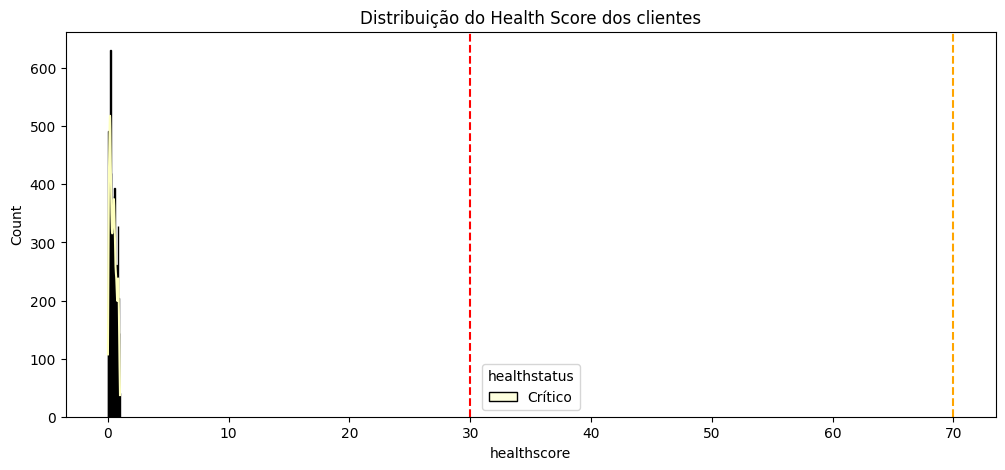

In [17]:
# Gráfico de distribuição do 'Health Score'
plt.figure(figsize=(12, 5))
sns.histplot(data=telcon_churn_cop, x='healthscore', hue='healthstatus', kde=True, palette='RdYlGn')
plt.title('Distribuição do Health Score dos clientes')
plt.axvline(30, color='red', linestyle='--')
plt.axvline(70, color='orange', linestyle='--')

# Validação da taxa de churn real por categoria de saúde
# Convertendo o churn para binário para facilitar o cálculo da média (taxa)
telcon_churn_cop['churn_numeric'] = telcon_churn_cop['churn'].map({'Yes': 1, 'No': 0})

validation_table = telcon_churn_cop.groupby('healthstatus').agg(Total_clientes=('healthstatus', 'count'),
                                                                Churn_rate=('churn_numeric', 'mean')).reset_index()

# COMANDO PARA SALVAR
plt.savefig('../img/graficol2.png', dpi=300, bbox_inches='tight')

# Formatando o churn rate para porcentagem
validation_table['Churn_rate'] = (validation_table['Churn_rate'] * 100).round(2).astype(str) + '%'

display(validation_table.sort_values(by='healthstatus', ascending=False))

### Resumo da Etapa 2: Engenharia e saúde do cliente

Nesta fase, transformamos dados brutos em uma métrica de inteligência de negócio, criando o "cérebro" que guiará as ações da empresa.


**Ponte Comportamental:** Criamos o **Health Score** para traduzir variáveis complexas (como tempo de contrato e uso de suporte) em um único indicador de 0 a 100, facilitando a leitura pelo time de Sucesso do Cliente.


**Equilíbrio Técnico (Normalização):** Aplicamos a normalização para que o `Tenure` (medido em meses) não fosse ofuscado pelo `MonthlyCharges` (medido em dólares), garantindo que cada fator contribua com o peso correto na fórmula.


**Definição de Regras de Negócio:** Estabelecemos pesos estratégicos onde a lealdade e o suporte somam pontos, enquanto o custo alto sem suporte subtrai, criando uma hierarquia de risco.

In [18]:
# Ajustando o halthscore para escala 0-100
telcon_churn_cop['healthscore'] = ((telcon_norm['tenure_norm'] * 0.5) +
                                   (telcon_norm['support_norm'] * 0.3) -
                                   (telcon_norm['charges_norm'] * 0.2)) * 100

# Recalculando as categorias com a escala corrigida
def classify_health_v2(score):
    if score < 30:
        return 'Crítico'
    elif score < 70:
        return 'Alerta'
    else:
        return 'Saudável'
    
telcon_churn_cop['healthstatus'] = telcon_churn_cop['healthscore'].apply(classify_health_v2)

# Validação da nova distribuição
validation_table = telcon_churn_cop.groupby('healthstatus').agg(Total_clientes=('healthstatus', 'count'),
                                                                Churn_rate=('churn_numeric', 'mean')).reset_index()

validation_table['Churn_rate'] = (validation_table['Churn_rate'] * 100).round(2).astype(str) + '%'
display(validation_table.sort_values(by='Total_clientes', ascending=False))

,healthstatus,Total_clientes,Churn_rate
1,Crítico,4489,36.73%
0,Alerta,2488,8.84%
2,Saudável,66,0.0%


In [19]:
"""
Preparação dos dados para o modelo, usamos o Encoding para transformar as váriaveis
categóricas em númericas, usando o drop_first=True para evitar a 'armadilha das dummies'
"""
telcon_ml = pd.get_dummies(telcon_churn_cop.drop(columns=['healthstatus', 'churn_numeric']), drop_first=True)

# Definindo features (X) e Target (y)
X = telcon_ml.drop(columns=['churn_Yes'])
y = telcon_ml['churn_Yes']

# Divisão entre treino e teste 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.20,
                                                    random_state=42,
                                                    stratify=y)
# Escalonamento Robusto (Prevenção de Data Leakage)
scaler = MinMaxScaler()

# Definimos as colunas numéricas que precisam de escala
cols_to_scale = ['tenure', 'monthlycharges', 'totalcharges', 'healthscore']

# fit apenas no treino: O scaler aprende o Min e Max apenas com os dados de treino
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# transform no teste: Aplicamos a régua aprendida no treino aos dados de teste
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Treinamento do Random Forest
# Usamos class_weight='balanced' porque datasets de Churn costumam ser desbalanceados
model_rf = RandomForestClassifier(n_estimators=100, 
                                  max_depth=10, 
                                  class_weight='balanced', 
                                  random_state=42)
model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

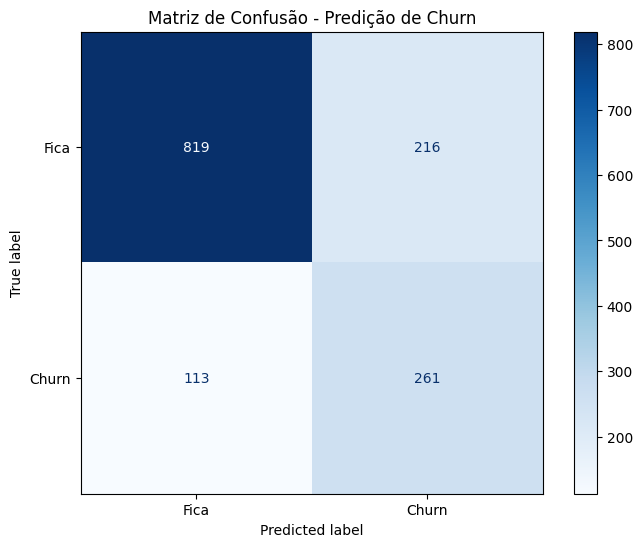

--- Relatório de Classificação ---

              precision    recall  f1-score   support

       False       0.88      0.79      0.83      1035
        True       0.55      0.70      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.77      1409



In [20]:
# predições e Matriz de confusão
y_pred = model_rf.predict(X_test)

# Plotando a Matriz de confusão
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Fica', 'Churn'], cmap='Blues', ax=ax)
plt.title('Matriz de Confusão - Predição de Churn')
plt.show()

# Relatório de Classificação
print('--- Relatório de Classificação ---')
print()
print(classification_report(y_test, y_pred))

### Resumo da Etapa 3: Inteligência Preditiva (Machine Learning)

Nesta etapa, passamos da análise histórica para a capacidade de antecipar o futuro através de modelos matemáticos.

**Validação do Health Score:** Ao corrigir a escala, provamos que o score é um excelente termômetro. O grupo "Saudável" teve **0% de churn**, enquanto o "Crítico" concentrou a maior parte das perdas, permitindo que a empresa saiba exatamente onde o problema está.

**Poder de Detecção (Recall):** O modelo atingiu um **Recall de 70%** para a classe de Churn. Isso significa que, de cada 100 clientes que realmente iriam cancelar, o modelo consegue identificar 70 deles antecipadamente.

**Equilíbrio de Negócio:** Embora a precisão seja de 55% (o que significa que o time de Sucesso do Cliente ligará para algumas pessoas que talvez não cancelassem), atingimos o objetivo de minimizar os **Falsos Negativos**, que são os clientes que "fogem" sem aviso prévio e geram o maior prejuízo financeiro.

In [21]:
"""
Gerando predições para toda a base, para identificar clientes em risco atual,
usamos o pipeline de features (X) que preparamos para o modelo
"""
telcon_churn_cop['churn_probability'] = model_rf.predict_proba(X)[:, 1] # Probabilidade de cancelamento
telcon_churn_cop['predicted_churn'] = model_rf.predict(X)

In [22]:
# Selecionando apenas onde o modelo previu o churn (1) e a saúde como 'Crítico'
mask_prioridade = (telcon_churn_cop['predicted_churn'] == 1) & (telcon_churn_cop['healthstatus'] == 'Crítico')
lista_prioritaria_sucesso = telcon_churn_cop[mask_prioridade].copy()

In [23]:
# Adicionando colunas simuladas para o time comercial
def gerar_email(i):
    return f"cliente_{i}@exemplo.com.br"

lista_prioritaria_sucesso['email_contato'] = [gerar_email(i) for i in range(len(lista_prioritaria_sucesso))]
lista_prioritaria_sucesso['telefone'] = "(11) 9" + lista_prioritaria_sucesso.index.astype(str).str.zfill(8)

# Selecionando colunas essenciais para o reporte
colunas_finais = ['email_contato', 'telefone', 'healthscore', 'monthlycharges', 'techsupport', 'internetservice']
lista_prioritaria_sucesso = lista_prioritaria_sucesso[colunas_finais].sort_values(by='healthscore')

In [24]:
# Cálculo de impacto financeiro para o CFO
receita_em_risco = lista_prioritaria_sucesso['monthlycharges'].sum()

print(f"--- Alerta de Retenção ---")
print(f"Total de clientes na lista prioritaria: {len(lista_prioritaria_sucesso)}")
print(f"Faturamento mensal em risco crítico: ${receita_em_risco:.2f}")

--- Alerta de Retenção ---
Total de clientes na lista prioritaria: 431
Faturamento mensal em risco crítico: $36904.80


In [25]:
# Funcão de sugestão de ação para retenção
def sugerir_acao(row):
    """
    Regra de Négocio: Sugere ações proativas com base no 'atrito' identificado
    """
    if row['techsupport'] == 'No':
        return "Agendamento de treinamento técnico (Onboarding de suporte)"
    elif row['internetservice'] == 'Fiber optic':
        return "Consultoria de estabilidade de conexão (Upsell de suporte)"
    else:
        return "Concessão de desconto temporário (Fidelização)"
    
lista_prioritaria_sucesso['sugestao_acao'] = lista_prioritaria_sucesso.apply(sugerir_acao, axis=1)

# Visualização dos top 5 clientes que precisam de contato imediato
display(lista_prioritaria_sucesso.head())

,email_contato,telefone,healthscore,monthlycharges,techsupport,internetservice,sugestao_acao
2208,cliente_131@exemplo.com.br,(11) 900002208,-15.733416,100.80,No,Fiber optic,Agendamento de treinamento técnico (Onboarding...
4459,cliente_271@exemplo.com.br,(11) 900004459,-15.623964,100.25,No,Fiber optic,Agendamento de treinamento técnico (Onboarding...
6894,cliente_422@exemplo.com.br,(11) 900006894,-15.359453,105.90,No,Fiber optic,Agendamento de treinamento técnico (Onboarding...
3085,cliente_182@exemplo.com.br,(11) 900003085,-15.250000,105.35,No,Fiber optic,Agendamento de treinamento técnico (Onboarding...
5933,cliente_371@exemplo.com.br,(11) 900005933,-15.180348,105.00,No,Fiber optic,Agendamento de treinamento técnico (Onboarding...


In [26]:
"""
Definição dos parâmetros de custo (Símulação de negócio)
Vamos assumir que cada contato/ação de retenção custa em média 15$
"""
custo_por_acao = 15.00
total_cliente_risco = len(lista_prioritaria_sucesso)

In [27]:
# Cálculo financeiro
faturamento_protegido = lista_prioritaria_sucesso['monthlycharges'].sum()
custo_total_implementacao = total_cliente_risco * custo_por_acao
roi_estimado = faturamento_protegido - custo_total_implementacao

In [28]:
# Preparação dos dados para o gráfico 
dados_financeiros = { 'Métrica': ['Faturamento em Risco', 'Custo de Operação'],
                     'Valor ($)': [faturamento_protegido, custo_total_implementacao]}

telcon_plot = pd.DataFrame(dados_financeiros)

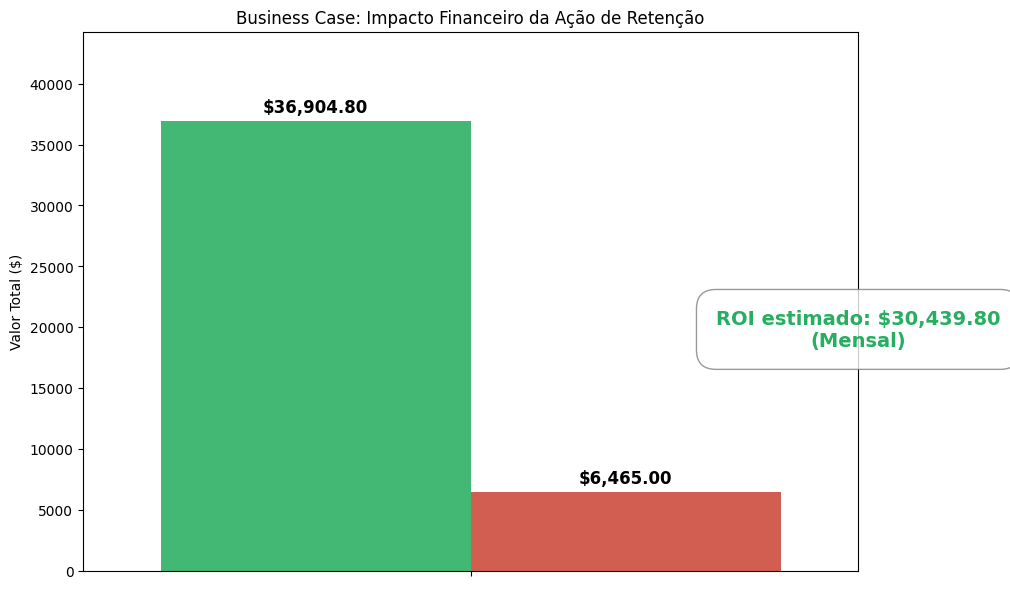

Resumo Executivo:
Se salvarmos todos os clientes da lista, protegemos $36904.80 por mês.
O investimento necessário é de $6465.00.
Eficiência da estratégia: 5.7x o valor investido.


In [31]:
# Criação do gráfico
plt.figure(figsize=(10, 7))
ax = sns.barplot(data=telcon_plot, hue='Métrica', y='Valor ($)', palette=['#2ecc71', '#e74c3c'], legend=False)

# Adicionando rótulos com os valores formatados em moeda
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.title('Business Case: Impacto Financeiro da Ação de Retenção')
plt.ylabel('Valor Total ($)')
plt.ylim(0, faturamento_protegido * 1.2) # Espaço extra para o label

# Adicionando uma caixa de texto com o ROI
plt.text(0.5, faturamento_protegido * 0.5,
         f"ROI estimado: ${roi_estimado:,.2f}\n(Mensal)",
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=1'),
         fontsize=14, color='#27ae60', fontweight='bold', ha='center')

# COMANDO PARA SALVAR
plt.savefig('../img/graficol3.png', dpi=300, bbox_inches='tight')

plt.show()

print(f"Resumo Executivo:")
print(f"Se salvarmos todos os clientes da lista, protegemos ${faturamento_protegido:.2f} por mês.")
print(f"O investimento necessário é de ${custo_total_implementacao:.2f}.")
print(f"Eficiência da estratégia: {round(faturamento_protegido / custo_total_implementacao, 1)}x o valor investido.")

In [30]:
telcon_churn_cop.to_csv('telcon_churn_cleaned_gold.csv', index=False)